In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [2]:
#Loading the dataset
df = pd.read_csv('medical_clean_D208.csv')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [83]:
#Selecting relevant columns for the analysis
columns = ["ReAdmis", "Age", "Complication_risk", "Initial_days", "TotalCharge"]

In [84]:
#Retaining only the selected columns needed for the analysis
df = df[columns]

In [85]:
#Checking for duplicate values
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [86]:
#Checking for missing values
print(df.isnull().sum())

ReAdmis              0
Age                  0
Complication_risk    0
Initial_days         0
TotalCharge          0
dtype: int64


In [87]:
#Converting categorical variable Readmis to a numeric variable
df['ReAdmis'] = df['ReAdmis'].map({'Yes': 1, 'No': 0})

In [88]:
#Converting categorical variable Complication_risk to a numeric variable
df['Complication_risk'] = df['Complication_risk'].map({'High': 2, 'Medium': 1, 'Low': 0})

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ReAdmis            10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Complication_risk  10000 non-null  int64  
 3   Initial_days       10000 non-null  float64
 4   TotalCharge        10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [90]:
#List of numerical columns for checking outliers
numerical_columns = ['TotalCharge', 'Age', 'Initial_days', 'Complication_risk', 'ReAdmis']

#Identify outliers based on Z-scores
z_scores = np.abs(zscore(df[numerical_columns]))
z_score_outliers = (z_scores > 3).sum(axis=0)
print("Outliers based on Z-score method:")
print(z_score_outliers)

Outliers based on Z-score method:
TotalCharge          0
Age                  0
Initial_days         0
Complication_risk    0
ReAdmis              0
dtype: int64


In [91]:
#Summary statistics for Initial days
print(df['Initial_days'].describe())

count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64


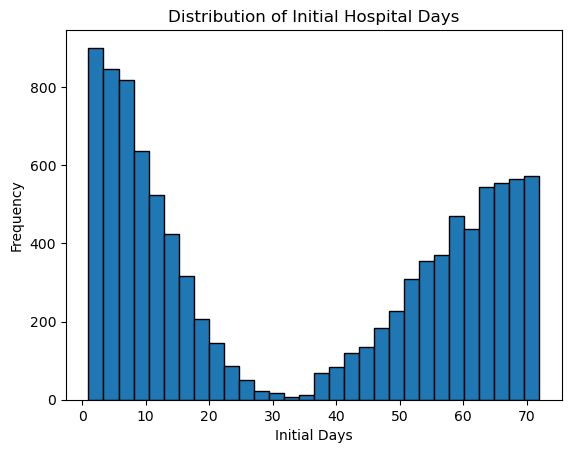

In [92]:
# Continuous variable 1: Distribution of Initial_days
plt.hist(df['Initial_days'], bins=30, edgecolor='black')
plt.title('Distribution of Initial Hospital Days')
plt.xlabel('Initial Days')
plt.ylabel('Frequency')
plt.show()

In [93]:
#Summary statistics for Age
print(df['Age'].describe())

count    10000.000000
mean        53.511700
std         20.638538
min         18.000000
25%         36.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64


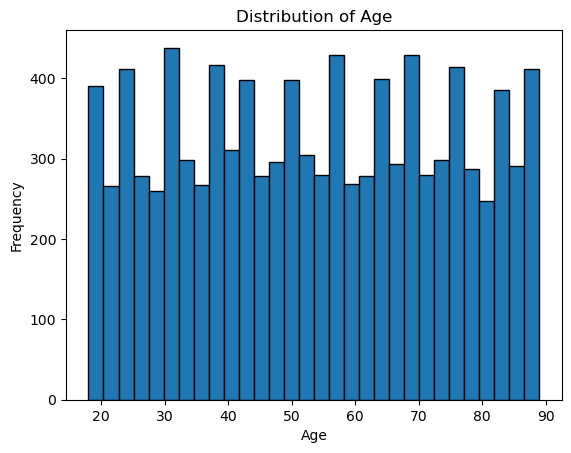

In [94]:
# Continuous variable 2: Distribution of Age
plt.hist(df['Age'], bins=30, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [95]:
#Summary statistics for Total Charge
print(df['TotalCharge'].describe())

count    10000.000000
mean      5312.172769
std       2180.393838
min       1938.312067
25%       3179.374015
50%       5213.952000
75%       7459.699750
max       9180.728000
Name: TotalCharge, dtype: float64


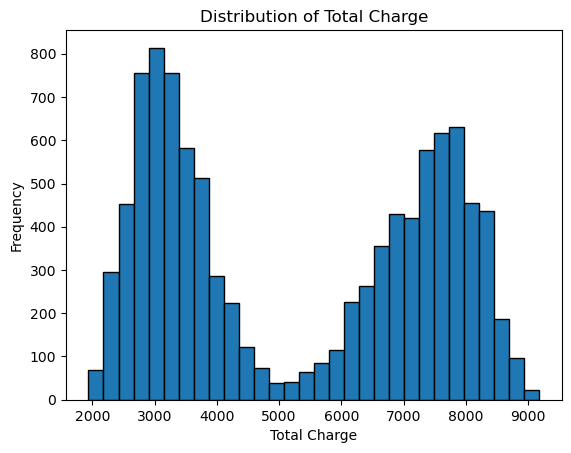

In [96]:
#Univariate distribution for Total Charge
plt.hist(df['TotalCharge'], bins=30, edgecolor='black')
plt.title('Distribution of Total Charge')
plt.xlabel('Total Charge')
plt.ylabel('Frequency')
plt.show()

In [97]:
#Summary statistics for ReAdmis
print(df['ReAdmis'].describe())

count    10000.000000
mean         0.366900
std          0.481983
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: ReAdmis, dtype: float64


In [98]:
#Value count for Readmission
print(df['ReAdmis'].value_counts())
#Univariate Statistics for ReAdmis variable
readmission = df['ReAdmis'].value_counts(normalize = True).mul(100).sort_values(ascending = False)
print('Relative frequency for Readmission:', readmission)

ReAdmis
0    6331
1    3669
Name: count, dtype: int64
Relative frequency for Readmission: ReAdmis
0    63.31
1    36.69
Name: proportion, dtype: float64


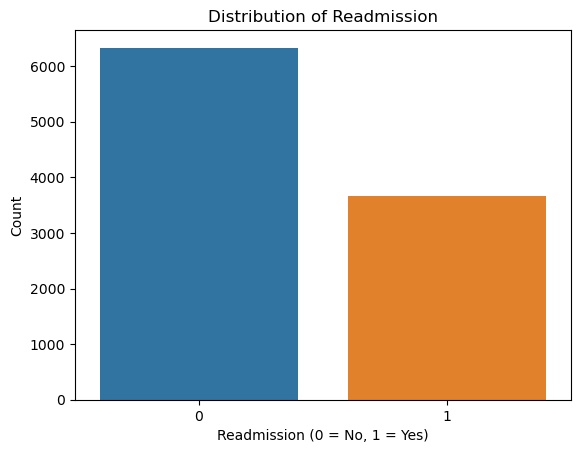

In [99]:
#Univariate statistics for Readmission
sns.countplot(data=df, x='ReAdmis')
plt.title('Distribution of Readmission')
plt.xlabel('Readmission (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [100]:
#Summary statistics for Complication risk
print(df['Complication_risk'].describe())

count    10000.000000
mean         1.123300
std          0.730172
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: Complication_risk, dtype: float64


In [101]:
#Value count for Complication risk
print(df['Complication_risk'].value_counts())
#Univariate Statistics for ReAdmis variable
risk = df['Complication_risk'].value_counts(normalize = True).mul(100).sort_values(ascending = False)
print('Relative frequency for Complication Risk:', risk)

Complication_risk
1    4517
2    3358
0    2125
Name: count, dtype: int64
Relative frequency for Complication Risk: Complication_risk
1    45.17
2    33.58
0    21.25
Name: proportion, dtype: float64


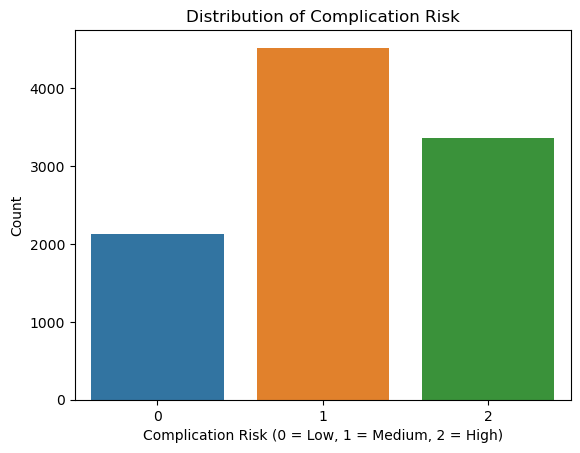

In [102]:
#Univariate statistics for Complication risk
sns.countplot(data=df, x='Complication_risk')
plt.title('Distribution of Complication Risk')
plt.xlabel('Complication Risk (0 = Low, 1 = Medium, 2 = High)')
plt.ylabel('Count')
plt.show()

In [103]:
#Bivariate analysis for Initial_days and Total Charge variables
pearson, _ = stats.pearsonr(df.Initial_days, df.TotalCharge)
print("Pearson correlation coefficient:")
print(pearson)

Pearson correlation coefficient:
0.9876402655398169


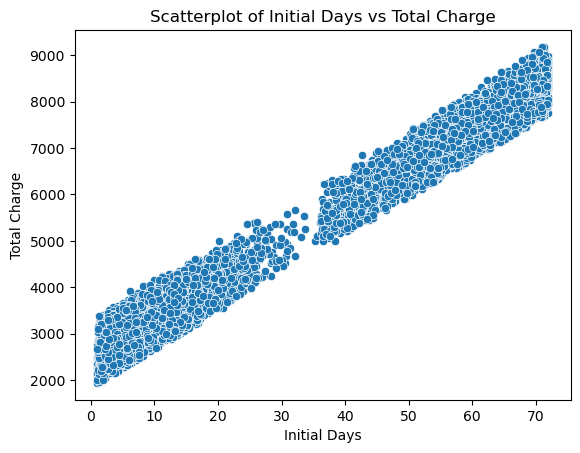

In [104]:
#Bivariate statistics for Initial days vs Total Charge
sns.scatterplot(data=df, x='Initial_days', y='TotalCharge')
plt.title('Scatterplot of Initial Days vs Total Charge')
plt.xlabel('Initial Days')
plt.ylabel('Total Charge')
plt.show()

In [105]:
#Bivariate analysis for Age vs Total Charge variables
pearson, _ = stats.pearsonr(df.Age, df.TotalCharge)
print("Pearson correlation coefficient:")
print(pearson)

Pearson correlation coefficient:
0.016875738075794233


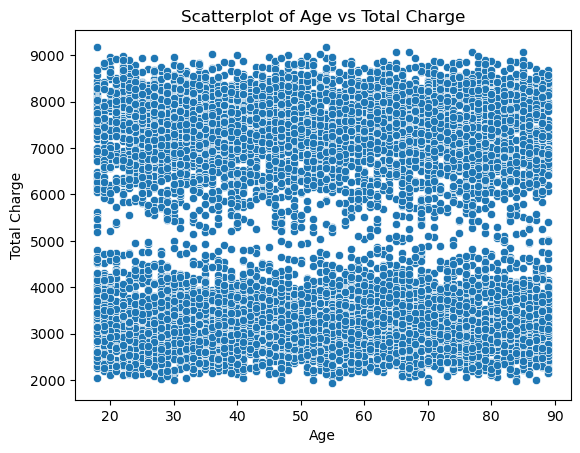

In [106]:
#Bivariate Statistics Scatterplot: Age vs Total Charge
sns.scatterplot(data=df, x='Age', y='TotalCharge')
plt.title('Scatterplot of Age vs Total Charge')
plt.xlabel('Age')
plt.ylabel('Total Charge')
plt.show()

In [107]:
#Bivariate analysis for Readmission vs Total Charge variables
pearson, _ = stats.pearsonr(df.ReAdmis, df.TotalCharge)
print("Pearson correlation coefficient:")
print(pearson)

Pearson correlation coefficient:
0.843725868324947


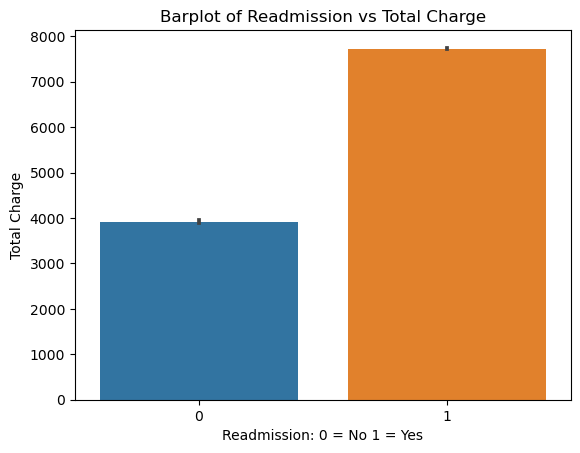

In [108]:
#Bivariate Statistics Barplot: Readmission vs Total Charge
sns.barplot(data=df, x='ReAdmis', y='TotalCharge')
plt.title('Barplot of Readmission vs Total Charge')
plt.xlabel('Readmission: 0 = No 1 = Yes')
plt.ylabel('Total Charge')
plt.show()

In [109]:
#Bivariate analysis for Complication_risk vs Total Charge variables
pearson, _ = stats.pearsonr(df.Complication_risk, df.TotalCharge)
print("Pearson correlation coefficient:")
print(pearson)

Pearson correlation coefficient:
0.06183405705001928


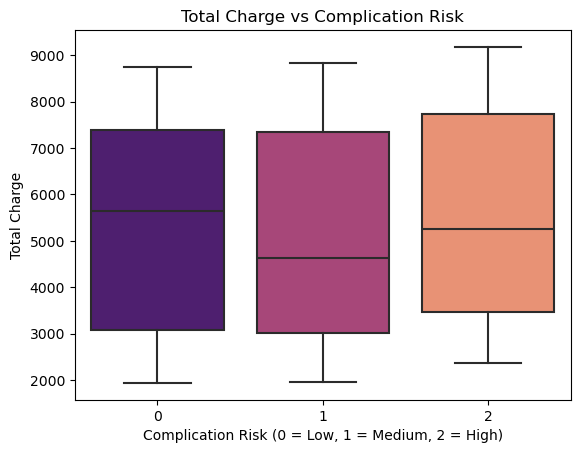

In [110]:
#Bivariate Statistics Barplot: Complication Risk vs Total Charge
sns.boxplot(data=df, x='Complication_risk', y='TotalCharge', palette='magma')
plt.title('Total Charge vs Complication Risk')
plt.xlabel('Complication Risk (0 = Low, 1 = Medium, 2 = High)')
plt.ylabel('Total Charge')
plt.show()

In [111]:
# Define dependent and independent variables
X = df[['Age', 'ReAdmis', 'Initial_days', 'Complication_risk']]
y = df['TotalCharge']

#Add Constant
X = sm.add_constant(X)

# Fit the model
initial_model = sm.OLS(y, X).fit()

# Display model summary
print(initial_model.summary())

                            OLS Regression Results                            
Dep. Variable:            TotalCharge   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 1.306e+05
Date:                Wed, 22 Jan 2025   Prob (F-statistic):               0.00
Time:                        00:46:41   Log-Likelihood:                -71184.
No. Observations:               10000   AIC:                         1.424e+05
Df Residuals:                    9995   BIC:                         1.424e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2238.7738     10.45

In [112]:
# Calculate VIF
X_vif =  df[['Age', 'ReAdmis', 'Initial_days', 'Complication_risk']]

#Add Constant
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\nVariance Inflation Factors:\n", vif_data)


Variance Inflation Factors:
              Feature        VIF
0              const  12.232244
1                Age   1.000288
2            ReAdmis   3.623831
3       Initial_days   3.624590
4  Complication_risk   1.000503


In [113]:
# Define reduced independent variables
X_reduced = df[['Initial_days', 'Complication_risk', 'ReAdmis']]

#Add Constant
X_reduced = sm.add_constant(X_reduced)

# Fit the reduced model
reduced_model = sm.OLS(y, X_reduced).fit()

# Display model summary
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:            TotalCharge   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 1.742e+05
Date:                Wed, 22 Jan 2025   Prob (F-statistic):               0.00
Time:                        00:47:18   Log-Likelihood:                -71184.
No. Observations:               10000   AIC:                         1.424e+05
Df Residuals:                    9996   BIC:                         1.424e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2241.8918      7.08

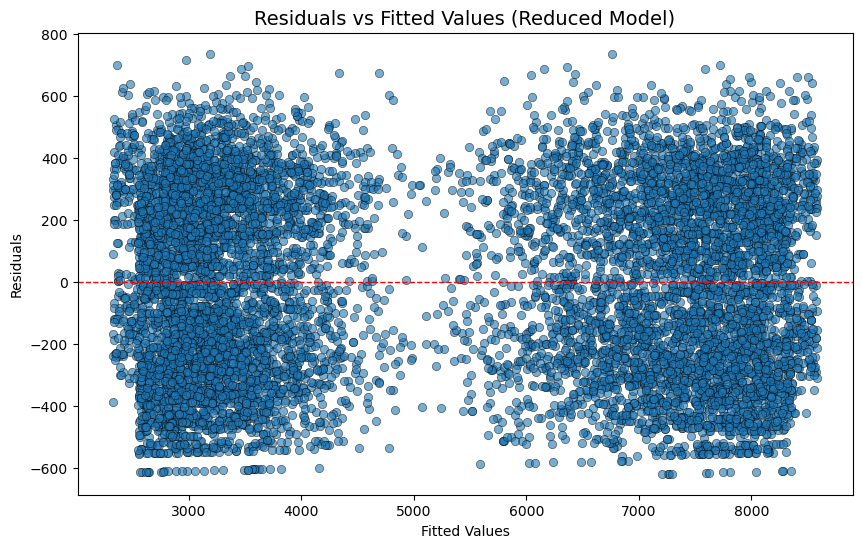

In [114]:
#Residuals
#Residuals from the reduced model
residuals = reduced_model.resid  
#Fitted values from the reduced model
fitted_values = reduced_model.fittedvalues 

#Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.6, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals vs Fitted Values (Reduced Model)', fontsize=14)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


In [115]:
# Generate predicted values
predicted_values = initial_model.predict(X)

# Calculate residuals
#residuals = y - predicted_values

# Save residuals back to the dataset
df['Residuals'] = residuals

# Display residuals
print("Residuals:")
print(df['Residuals'])

Residuals:
0       398.128510
1       268.845655
2      -421.984350
3      -479.981954
4      -230.771918
           ...    
9995    193.102533
9996   -350.403539
9997   -162.931746
9998    -16.062896
9999   -155.270770
Name: Residuals, Length: 10000, dtype: float64


In [116]:
# Calculate the Residual Standard Error (RSE)
RSE = np.sqrt(sum(residuals**2) / (len(residuals) - 2))
print(f'Residual Standard Error: {RSE}')

Residual Standard Error: 298.74057718587846


In [117]:
coefficients = reduced_model.params

# Build the regression equation
terms = [f"{coef:.2f}*{var}" if var != "const" else f"{coef:.2f}" for var, coef in coefficients.items()]
equation = " + ".join(terms)

# Print the regression equation
print("Regression Equation:")
print(f"TotalCharge = {equation}")


Regression Equation:
TotalCharge = 2241.89 + 81.25*Initial_days + 226.59*Complication_risk + 44.30*ReAdmis


In [118]:
print(reduced_model.params)

const                2241.891807
Initial_days           81.250239
Complication_risk     226.586227
ReAdmis                44.304614
dtype: float64


In [119]:
# Save cleaned dataset
new_data_path = 'output/new_medical_data_D208_I.csv'
df.to_csv(new_data_path, index=False)